<a href="https://www.kaggle.com/code/samratrm/ola-drivers-attrition-ensemble?scriptVersionId=336486481" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# OLA - Ensemble 

(Scaler - Business case study)

Date: 19 July 2026 

Email: `samratrm2@gmail.com`

### Problem statement:

Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola, focused on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like

- Demographics (city, age, gender etc.)
- Tenure information (joining date, Last Date)
- Historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

### Dataset:

**Column Profiling:**

`MMMM-YY` : Reporting Date (Monthly) - Renamed to `Report_Date`

`Driver_ID` : Unique id for drivers

`Age` : Age of the driver

`Gender` : Gender of the driver – Male : 0, Female: 1

`City` : City Code of the driver

`Education_Level` : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate

`Income` : Monthly average Income of the driver

`Date Of Joining` : Joining date for the driver

`LastWorkingDate` : Last date of working for the driver

`Joining Designation` : Designation of the driver at the time of joining where a higher number typically indicates a higher starting tier or senior role.

`Grade` : Grade of the driver at the time of reporting

`Total Business Value` : The total business value acquired by the driver in a month (negative business indicates cancellation/refund or car EMI adjustments)

`Quarterly Rating` : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

The Difference between `Grade` and `Date Of Joining` : It captures their starting point at the company, whereas the grade column represents their level at the time of that month's reporting. Comparing joining_designation to grade is highly valuable because it tells you if a driver has been promoted during their tenure.

### Objective:

The core objective of this case study is to predict driver churn for Ola and uncover the underlying factors contributing to high attrition rates. To achieve this, the notebook follows an end-to-end machine learning pipeline:

1. Data Processing & Engineering: Aggregating monthly driver records,resolving missing values during aggregation, with KNN imputation demonstrated on masked data and engineering predictive features (such as quarterly rating and income trends).

2. Predictive Modeling: Addressing class imbalances and training robust Ensemble Learning models (Bagging and Boosting) to classify whether a driver will leave the company.

3. Business Impact: Evaluating model performance to translate data-driven insights into actionable retention strategies for Ola's Analytics Department.

#### Solution Appraoch - What This Notebook Uncovers

Two out of every three drivers in this dataset have already walked out the door. So instead of asking the obvious question ("who's going to leave?"), this notebook flips it: who actually stays, and can we spot them before the retention budget goes up in smoke? 

The journey runs end to end, from aggregating messy monthly records into driver-level stories, through an EDA that quietly dismantles a few assumptions (spoiler: gender and education tell us nothing, but a missing raise tells us almost everything), to a bake-off between Random Forest and XGBoost with a detour into the imbalance-handling debate where SMOTE gets politely shown the exit. Along the way, two findings steal the show: 

> a targeted raise turns out to be far cheaper than the acquisition cost of replacing a driver

and
> the earliest visible symptom of churn is not a resignation letter but a quarterly rating that drops or simply flatlines.

By the end, a cost-sensitive Weighted XGBoost earns the production slot, not because it topped every leaderboard metric, but because it is the best at the job that actually matters: finding the loyal drivers worth keeping.

## Data Understanding

In [1]:
!pip install imbalanced-learn

In [2]:
import numpy as np
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn
import math
import xgboost
import imblearn

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/samratrm/ola-dataset/ola_driver_scaler.csv


In [4]:
df = pd.read_csv("/kaggle/input/datasets/samratrm/ola-dataset/ola_driver_scaler.csv")
df.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [5]:
df.shape

(19104, 14)

#### Feature renaming and Index reset

In [6]:
(df['Unnamed: 0'] != df.index).sum() # same as index 

np.int64(0)

In [7]:
rename_dict = {
    'MMM-YY': 'report_date',
    'Driver_ID': 'driver_id',
    'Age': 'age',
    'Gender': 'gender',
    'City': 'city',
    'Education_Level': 'education_level',
    'Income': 'income',
    'Dateofjoining': 'date_of_joining',
    'LastWorkingDate': 'last_working_date',
    'Joining Designation': 'joining_designation',
    'Grade': 'grade',
    'Total Business Value': 'total_business_value',
    'Quarterly Rating': 'quarterly_rating'
}

df = df.drop(columns='Unnamed: 0').rename(columns=rename_dict)
df.head()

,report_date,driver_id,age,gender,city,education_level,income,date_of_joining,last_working_date,joining_designation,grade,total_business_value,quarterly_rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


**Summary:** Drops the redundant index column and standardizes all feature names into a consistent `snake_case` format for cleaner data manipulation.

#### Missing Values

In [8]:
missing_val = df.isna().sum() 
missing_val[missing_val > 0 ]

age                     61
gender                  52
last_working_date    17488
dtype: int64

#### Duplicate Rows

In [9]:
# monthly data and index col not included
column_list = ['report_date', 'age', 'gender', 'city', 'education_level',
       'income', 'date_of_joining', 'last_working_date', 'joining_designation']
df[column_list].duplicated().sum()

np.int64(0)

**Summary:**

- The `last_working_date` missing values are used to create the target variable. So, We will not fill it or aggregate it. 
- The `age` and `gender` will be imputated after the train, test and validation data split to avoid data leak. 
- There is no duplicate rows in the dataset.

#### Date Datatype Conversion

In [10]:
df['last_working_date'] = pd.to_datetime(df['last_working_date'], format='%d/%m/%y', errors='coerce')
df['report_date'] = pd.to_datetime(df['report_date'], format='%m/%d/%y', errors='coerce')
df['date_of_joining'] = pd.to_datetime(df['date_of_joining'], format='%d/%m/%y', errors='coerce')

**Summary:** 

- `report_date` is formatted as `MM/DD/YY` (e.g., `12/01/20` is December 1, 2020).

- `date_of_joining` and `last_working_date` are formatted as `DD/MM/YY` (e.g., `24/12/18` is December 24, 2018).

- This update converts parses text dates into proper datetimes.

**Note:** The other quantative and categorical data will be converted after Feature Engieneering since it requires aggregation on column data. 

## Feature Engineering

### Target Variable Creation

A missing value (`NaN`) in the `last_working_date` column indicates that the driver is currently active and employed at Ola. Conversely, a recorded date indicates the driver has officially left the company.

Since our objective is to predict driver churn, we can engineer a binary target variable `is_churned` directly from this column:

Class 1 (Churned): Drivers who have left the company (where `last_working_date` is not null).

Class 0 (Active): Drivers who are currently employed (where `last_working_date` is null).

In [11]:
df['is_churned'] = df['last_working_date'].notna().astype(int)
df['is_churned'][:5]

0    0
1    0
2    1
3    0
4    0
Name: is_churned, dtype: int64

**Note:**

- We will not fill these `NaN` values in `last_working_date` with dummy dates or use KNN imputation on this column. Since `last_working_date` is the source of our target variable (`is_churned`), **altering these nulls will corrupt our target labels**.
- The `last_working_date` column's data will be extracted into other features like `tenure` , etc during feature engineering. 
- We will fill in `age` and `gender` after the train, test and validation data split to avoid data leakage. 

In [12]:
df[df['driver_id'] == 2787]

,report_date,driver_id,age,gender,city,education_level,income,date_of_joining,last_working_date,joining_designation,grade,total_business_value,quarterly_rating,is_churned
19091,2019-01-01,2787,28.0,1.0,C20,2,69498,2018-07-21,NaT,1,1,408090,2,0
19092,2019-02-01,2787,28.0,1.0,C20,2,69498,2018-07-21,NaT,1,1,250000,2,0
19093,2019-03-01,2787,28.0,1.0,C20,2,69498,2018-07-21,NaT,1,1,319740,2,0
19094,2019-04-01,2787,28.0,1.0,C20,2,69498,2018-07-21,NaT,1,1,0,1,0
19095,2019-05-01,2787,28.0,1.0,C20,2,69498,2018-07-21,NaT,1,1,0,1,0
19096,2019-06-01,2787,28.0,1.0,C20,2,69498,2018-07-21,2019-06-20,1,1,0,1,1


If a driver churned then the `last_worked_date` stay `NaT` in a churned driver's earlier rows and appear only in their final row 

In [13]:
df['driver_id'].nunique() , df.shape[0]

(2381, 19104)

**Why feature engineering precedes EDA here**

This dataset is monthly panel data: ~19,100 rows but only ~2,381 unique drivers, each appearing once per month of employment. Our prediction unit is the driver, not the driver-month. 

So we first restructure to one row per driver, and this restructuring requires feature engineering: monthly history must be summarized (business value sums, trend flags like rating/income increased, tenure) or it's lost. EDA is only meaningful on this driver-level frame.

**Why this is not data leakage**

Leakage means information from the test set (or from the future/target) influencing training. Neither happens here:

- Every engineered feature is computed within a single driver's own history and no driver's features use another driver's data.
- The train/test split happens at the driver level, so a driver's rows never straddle the split.
- No dataset-wide statistics (means, encodings, imputations) are fit before splitting and those steps come after the split, fit on train only.

Leakage would occur if we imputed age/gender using full-dataset statistics before splitting. Which is exactly why imputation is deferred until pipeline building step.

In [14]:
driver_df = df.groupby("driver_id").agg(
    # static 
    gender=('gender','first'),
    education_level=('education_level','first'),
    city=('city','first'),
    date_of_joining=('date_of_joining','first'),
    joining_designation=('joining_designation','first'),
    first_income=('income','first'),
    first_rating=('quarterly_rating','first'),

    # Most recent state 
    age=('age','last'),
    report_date=('report_date','last'),
    last_working_date=('last_working_date','last'),
    grade=('grade','last'),
    last_income=('income', 'last'),
    last_rating=('quarterly_rating','last'),

    # Business values (aggregate)
    total_business_value_sum=('total_business_value', 'sum'),
    total_business_value_mean=('total_business_value', 'mean'),
    total_business_value_std=('total_business_value', 'std'),
    avg_quarterly_rating=('quarterly_rating','mean'),
    
    # Target flag
    is_churned=('is_churned', 'max')
)


# New Features 
driver_df['year_of_joining'] = driver_df['date_of_joining'].dt.year

driver_df['income_increase'] = (driver_df['last_income'] > driver_df['first_income']).astype(int)

driver_df['rating_increment'] = driver_df['last_rating'] - driver_df['first_rating']
driver_df['rating_increase'] = (driver_df['rating_increment'] > 0).astype(int)

driver_df['grade_increment'] = driver_df['grade'] - driver_df['joining_designation']
driver_df['grade_increase'] = (driver_df['grade_increment'] > 0).astype(int)

max_date = df['report_date'].max()
driver_df['tenure_days'] = (driver_df['last_working_date'].fillna(max_date) - driver_df['date_of_joining']).dt.days

# Handle NaNs
print("Empty total_business_value_std rows:", driver_df['total_business_value_std'].isna().sum())
driver_df['total_business_value_std'] = driver_df['total_business_value_std'].fillna(0)

print("Empty last_working_date:",driver_df['last_working_date'].isna().sum())

print("Negative tenure days rows :", (driver_df['tenure_days'][driver_df['tenure_days'] < 0]).count())
driver_df['tenure_days'] = driver_df['tenure_days'].clip(lower=0)

driver_df.head()

Empty total_business_value_std rows: 181
Empty last_working_date: 765
Negative tenure days rows : 175


,gender,education_level,city,date_of_joining,joining_designation,first_income,first_rating,age,report_date,last_working_date,...,total_business_value_std,avg_quarterly_rating,is_churned,year_of_joining,income_increase,rating_increment,rating_increase,grade_increment,grade_increase,tenure_days
driver_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,2,C23,2018-12-24,1,57387,2,28.0,2019-03-01,2019-11-03,...,1.601755e+06,2.0,1,2018,0,0,0,0,0,314
2,0.0,2,C7,2020-06-11,2,67016,1,31.0,2020-12-01,NaT,...,0.000000e+00,1.0,0,2020,0,0,0,0,0,173
4,0.0,2,C13,2019-07-12,2,65603,1,43.0,2020-04-01,2020-04-27,...,1.565248e+05,1.0,1,2019,0,0,0,0,0,290
5,0.0,0,C9,2019-09-01,1,46368,1,29.0,2019-03-01,2019-07-03,...,6.948988e+04,1.0,1,2019,0,0,0,0,0,0
6,1.0,1,C11,2020-07-31,3,78728,1,31.0,2020-12-01,NaT,...,5.657252e+05,1.6,0,2020,0,1,1,0,0,123


In [15]:
display(driver_df.shape, driver_df.index.name)
driver_df.columns

(2381, 25)

'driver_id'

Index(['gender', 'education_level', 'city', 'date_of_joining',
       'joining_designation', 'first_income', 'first_rating', 'age',
       'report_date', 'last_working_date', 'grade', 'last_income',
       'last_rating', 'total_business_value_sum', 'total_business_value_mean',
       'total_business_value_std', 'avg_quarterly_rating', 'is_churned',
       'year_of_joining', 'income_increase', 'rating_increment',
       'rating_increase', 'grade_increment', 'grade_increase', 'tenure_days'],
      dtype='object')

**Feature Engineering Summary:** 
* **Data Structure:** Collapsed ~19K monthly records into ~2,381 unique driver profiles using `groupby('driver_id')` and the `driver_id` is the index of the new dataframe.
* **Static & Onboarding Features:** Captured baseline traits using the `first` record (e.g., `gender`, `city`, `education_level`, `date_of_joining`, `joining_designation`).
* **Most Recent Profile:** Retained the driver's latest status using the `last` record (e.g., `age`, `grade`, `last_income`, `last_rating`).
* **Target Column:** Created `is_churned` by checking the presence of a `last_working_date`.
* **Business Value Metrics:** Created `sum`, `mean`, and `std` of monthly business acquired to track overall volume and consistency.
* **Income Progression:** Engineered `income_increase` (binary flag indicating if final income exceeds starting income).
* **Rating Trajectory:** Computed `avg_quarterly_rating`, `rating_increment` (exact value change), and `rating_increase` (binary flag).
* **Career Promotion:** Added `grade_increment` (change in tier levels) and `grade_increase` (binary flag for promotions).
* **Driver Tenure:** Generated `tenure_days` using the span between joining date and exit date (or the max dataset date for active drivers).
* `year_of_joining` year of joining Ola becuase joining cohort matters. 2020 joiners faced COVID-era demand collapse later joiners might have shorter possible tenure.
 
* **Missing Values & Anomalies:**
    * `last_working_date`: Left empty to prevent target leakage.
    * `tenure_days`: Clipped negative values to 0.
    * `total_business_value_std`: Filled missing values with 0 (occurs for drivers with only a single month of data).

In [16]:
driver_df[['age','gender']].isna().sum()

age       0
gender    0
dtype: int64

**Note:** 
- Age and gender had nulls only in some monthly rows, not for entire drivers. During driver-level aggregation, `first/last` skip nulls and pick each driver's own recorded value, so the missingness resolved itself using within driver data to recover the real values, not imputation. No cross-driver information was used, so there is no leakage.
- KNN imputation is therefore demonstrated separately on masked data to cover the required technique.
- Since there was a lot of aggregation. We are doing the data type conversion after feature engineering.

#### Datatype Conversion for Numerical and Categorical features

In [17]:
# After Aggregation Now convert these columns to category 

dtype_dict = {
    
    # Categorical / Binary Features (ideal for tree groupings and memory optimization)
    'gender': 'category',
    'education_level': 'category',
    'city': 'category',
    'joining_designation': 'category',
    'grade': 'category',
    'first_rating': 'category',
    'last_rating': 'category',
    'is_churned': 'category',
    'income_increase': 'category',
    'rating_increase': 'category',
    'grade_increase': 'category',
    'year_of_joining': 'category', 
    
    # Numerical Features (Discrete / Nullable Integers that support NaNs)
    'age': 'Int64',
    'grade_increment': 'Int64',
    'rating_increment': 'Int64',
    'tenure_days': 'Int64',
    
    # Numerical Features (Continuous Floats)
    'first_income': 'float64',
    'last_income': 'float64',
    'total_business_value_sum': 'float64',
    'total_business_value_mean': 'float64',
    'total_business_value_std': 'float64',
    'avg_quarterly_rating': 'float64'
}

# Apply the conversions to df_driver
driver_df = driver_df.astype(dtype_dict)

# Verify types and check memory usage reduction
driver_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2381 entries, 1 to 2788
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   gender                     2381 non-null   category      
 1   education_level            2381 non-null   category      
 2   city                       2381 non-null   category      
 3   date_of_joining            2381 non-null   datetime64[ns]
 4   joining_designation        2381 non-null   category      
 5   first_income               2381 non-null   float64       
 6   first_rating               2381 non-null   category      
 7   age                        2381 non-null   Int64         
 8   report_date                2381 non-null   datetime64[ns]
 9   last_working_date          1616 non-null   datetime64[ns]
 10  grade                      2381 non-null   category      
 11  last_income                2381 non-null   float64       
 12  last_rating

# Exploratory Data Analysis

### Target Analysis

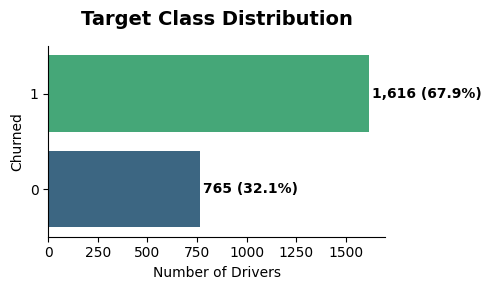

In [18]:
counts = driver_df['is_churned'].value_counts()
percentages = driver_df['is_churned'].value_counts(normalize=True) * 100 

plt.figure(figsize=(5, 3))
ax = sns.barplot(x=counts.values, y=counts.index.astype(str), palette='viridis',hue=counts.index, legend=False)
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    x_position = count + (counts.values.max() * 0.01)
    label_text = f'{count:,} ({pct:.1f}%)'    
    ax.text(x_position, i, label_text, va='center', ha='left', weight='bold', fontsize=10)

plt.title('Target Class Distribution', fontsize=14, pad=15, weight='bold')
plt.xlabel('Number of Drivers')
plt.ylabel('Churned')
sns.despine()  # Removes top and right borders
plt.tight_layout()
plt.show()

**Target Analysis Summary:**

- 2,381 rows is fine for tree ensembles. RF/XGBoost genreally works well at this scale.
- 7:3 is mild imbalance. With `class_weight='balanced'` or `scale_pos_weight` attributes imbalance will not cause model to be biased.
- The minority class is "stayed" drivers. Which means the model's harder job is identifying loyal drivers, not churners.
-  SMOTE would be over-engineering because Synthetic oversampling on small datasets often creates artificial "bridge" points between tightly packed decision boundaries. Because decision trees create orthogonal splits, they will draw hyper-specific boxes around these fake SMOTE points, leading to severe overfitting.

**Insight:** Having a small dataset will cause noisy evaluation. The test set will be ~476 drivers and a few flips will move metrics by ~1%. So we can use **stratified k-fold cross-validation** for model comparison and tuning.

**Note:** SMOTE is considered and rejected but since Scaler's BCS description requires it we will do it in a seperate section and compare the results. 

## Numerical Univariate Analysis

In [19]:
business_feats = [ 'total_business_value_sum','total_business_value_mean','total_business_value_std']
log_business_feats = [ 'total_business_value_sum_log','total_business_value_mean_log','total_business_value_std_log']
driver_df[log_business_feats] = np.sign(driver_df[business_feats]) * np.log1p(np.abs(driver_df[business_feats]))
driver_df[log_business_feats].describe()

,total_business_value_sum_log,total_business_value_mean_log,total_business_value_std_log
count,2381.000000,2381.000000,2381.000000
mean,10.094935,8.640158,8.920197
std,6.989671,5.950935,5.902936
min,-14.141594,-12.195688,0.000000
25%,0.000000,0.000000,0.000000
50%,13.614228,11.922552,12.208723
75%,15.244302,12.970376,13.087060
max,18.372866,15.194813,15.904181


Let's scale the business features since they have a massive right skew and they are not interpretable in the histogram. 

In [20]:
num_feats = driver_df.select_dtypes(include='number').columns.tolist()
for feat in business_feats:
    num_feats.remove(feat)
f = pd.melt(driver_df, value_vars=num_feats)
f.head()

,variable,value
0,first_income,57387.0
1,first_income,67016.0
2,first_income,65603.0
3,first_income,46368.0
4,first_income,78728.0


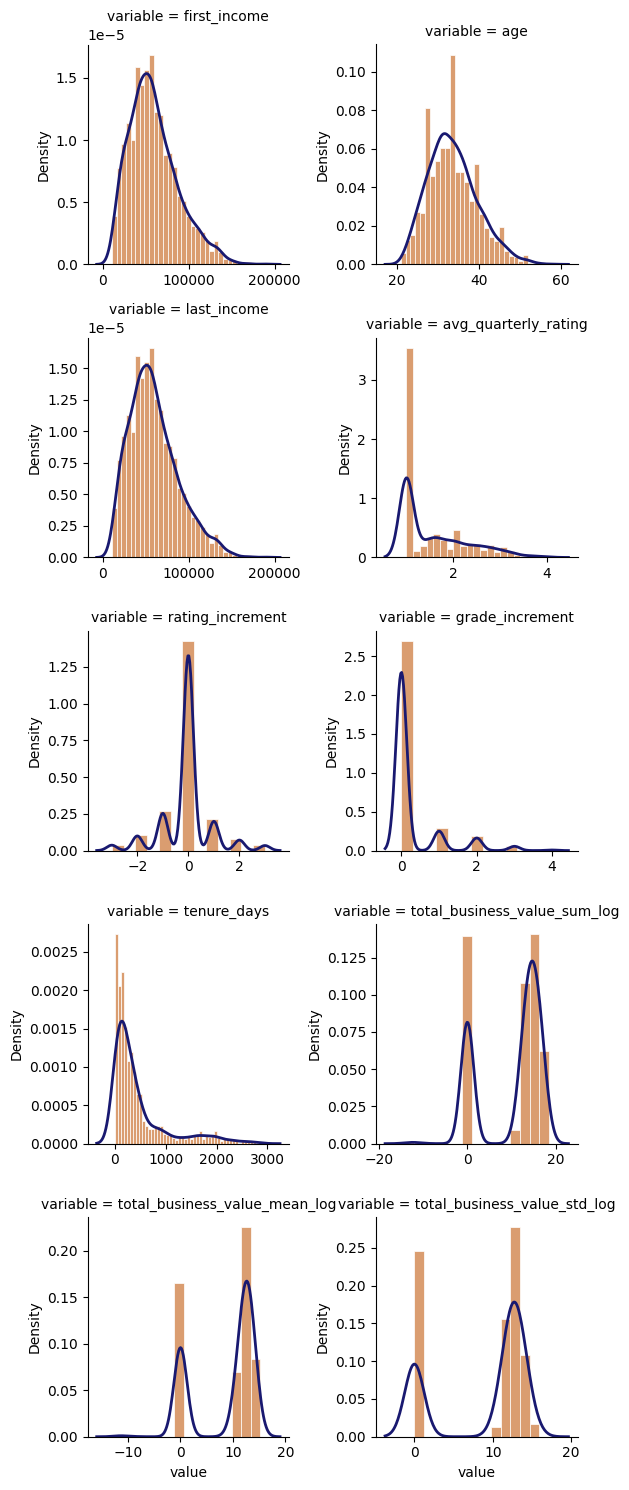

In [21]:
g = sns.FacetGrid(f, col="variable", col_wrap=2, sharex=False, sharey=False)
g = g.map(sns.histplot, "value", color="#CE7D40", edgecolor="white", linewidth=0.5, alpha=0.75, stat="density").map(sns.kdeplot, "value", color="#191970", linewidth=2)

In [22]:
n = driver_df.shape[0]
print('Differnet first and last income :',driver_df[driver_df['first_income'] != driver_df['last_income']].shape[0]/ n)
print('Zero grade increment :',(driver_df[driver_df['grade_increment'] == 0]).shape[0]/ n)
print('Zero rating increment :',(driver_df[driver_df['rating_increment'] == 0]).shape[0]/n)
print('Negative rating increment :',(driver_df[driver_df['rating_increment'] < 0]).shape[0]/n)
print('Lowest average quarterly rating :',driver_df[driver_df['avg_quarterly_rating'] == 1].shape[0]/n)

Differnet first and last income : 0.018059638807223857
Zero grade increment : 0.8290634187316254
Zero rating increment : 0.6572868542629148
Negative rating increment : 0.19235615287694247
Lowest average quarterly rating : 0.504829903401932


**Numeric Data Univariate Analysis:**

- Only ~1.8% of `first_income` and `last_income` are differnet. It's unimodala and slightly right skewed. Expecting very high collinearity during the Collinearity analysis. 
- The business metircs sum and mean are bimodal with a huge peak in the 0 and a huge peak near the 20K-2lahk (10-14 in log scale) which can be interpreted as drivers that are completely inactive and the drivers that are active.
- ~83% of drivers had no increment in their grade during their tenure in Ola.
- ~65% of drivers have no increment in their rating and the rating has a unimodal distribution with a tail on both side showing that there are ~19% drivers that had declined in their rating during their tenure. 
- ~50% of the drivers had the lowest quarterly rating during their tenure.

**Hypothesis:** 
- H1: Drivers who have 0 business value are inactive drivers who probably have high churn rate.
- H2: Negative rating and zero increment in rating drivers probably have high churn rate.
- H3: First and Last income features are redundant and one of them can be dropped.

These can be tested in the bivariate analysis and correlation section.


#### Testing H1 Hypothesis

In [23]:
value_status = (driver_df['total_business_value_sum'] > 0).map({True: 'Positive', False: 'Negative/Zero'})
print(pd.crosstab(value_status, driver_df['is_churned'], normalize='index') * 100)

is_churned                        0          1
total_business_value_sum                      
Negative/Zero             22.908093  77.091907
Positive                  36.198547  63.801453


- The average churn rick for any drier in this dataset is ~69%
- The churned rate negative and zero total_business_value drivers are only ~13pp higher than the positive business value drivers which means that the H1 hypothesis is true but a weak signal.
- The churn is endemic across all the segments, not localized to inactive drivers.

**Insight:** Endemic churn means that the retain intervension is significant to all the drivers. 

## Numerical Bivariate Analysis

In [24]:
bivariate_f = pd.melt(driver_df, id_vars=['is_churned'], value_vars=num_feats)
bivariate_f.head()

,is_churned,variable,value
0,1,first_income,57387.0
1,0,first_income,67016.0
2,1,first_income,65603.0
3,1,first_income,46368.0
4,0,first_income,78728.0


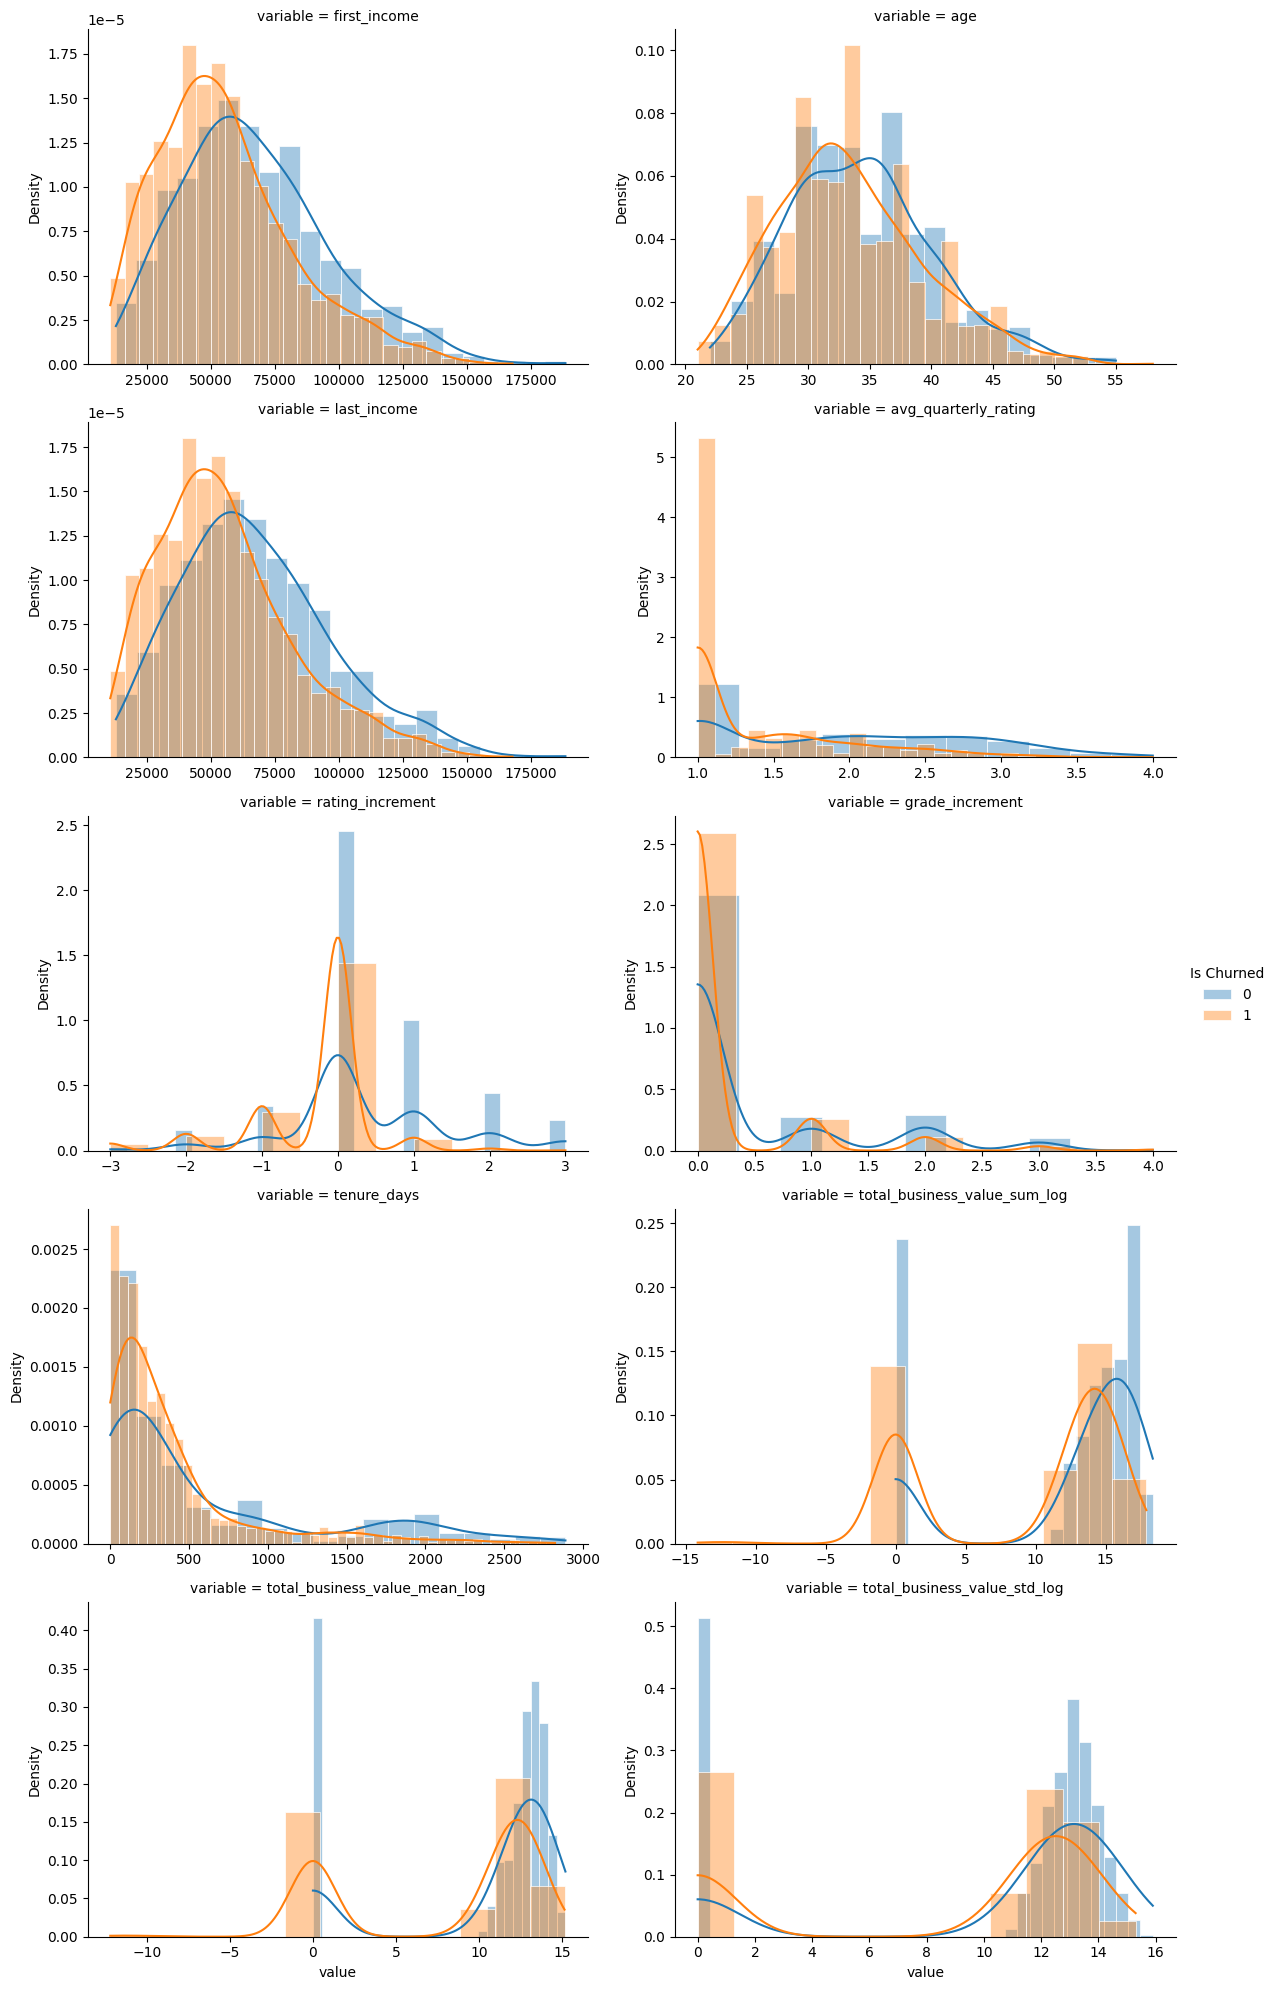

In [25]:
bivariate_g = sns.FacetGrid(bivariate_f, col="variable", col_wrap=2, hue="is_churned", palette=['#1f77b4', '#ff7f0e'], sharex=False, sharey=False, height=4, aspect=1.5)
bivariate_g.map_dataframe(sns.histplot, x="value", kde=True, alpha=0.4, edgecolor="white", linewidth=0.5, stat="density", common_norm=False)
bivariate_g.add_legend(title="Is Churned")

**Numerical Bivariance Analysis Summary:**

- Lower-income drivers (<60K) exhibit a disproportionately high churn rate compared to higher income brackets.

- Churn peaks noticeably in the younger demographic (<35). It's a weak - moderate signal and can be speculated as younger demographic drivers have more career mobility and easily pivot to alternative opportunities.

- Drivers with the lowest average rating (1) show a severe spike in attrition, churning at nearly twice the rate of active drivers with 1 average rating.

- Stagnant or negative rating increments are a strong warning sign of churn, whereas drivers experiencing positive rating growth show significantly higher retention.

- A similar trend appears with career progression: drivers stuck at lower grades or seeing zero grade increments churn at much higher rates than those moving up.

- While the 0-day tenure group consists entirely of active new sign-ups, the real risk window is concentrated in the early lifecycle—specifically among drivers with under 750 tenure days. It's a weak signal alone since short tenure partly reflects construction, not just risk.

- Total business value shows a clear inverse relationship with attrition: high-value drivers have significantly lower churn rates, highlighting that our top earners are the most stable.

## Correlation Heatmap

In [26]:
for i in range(3):
    num_feats.remove(log_business_feats[i])
    num_feats.append(business_feats[i])
print(num_feats)

['first_income', 'age', 'last_income', 'avg_quarterly_rating', 'rating_increment', 'grade_increment', 'tenure_days', 'total_business_value_sum', 'total_business_value_mean', 'total_business_value_std']


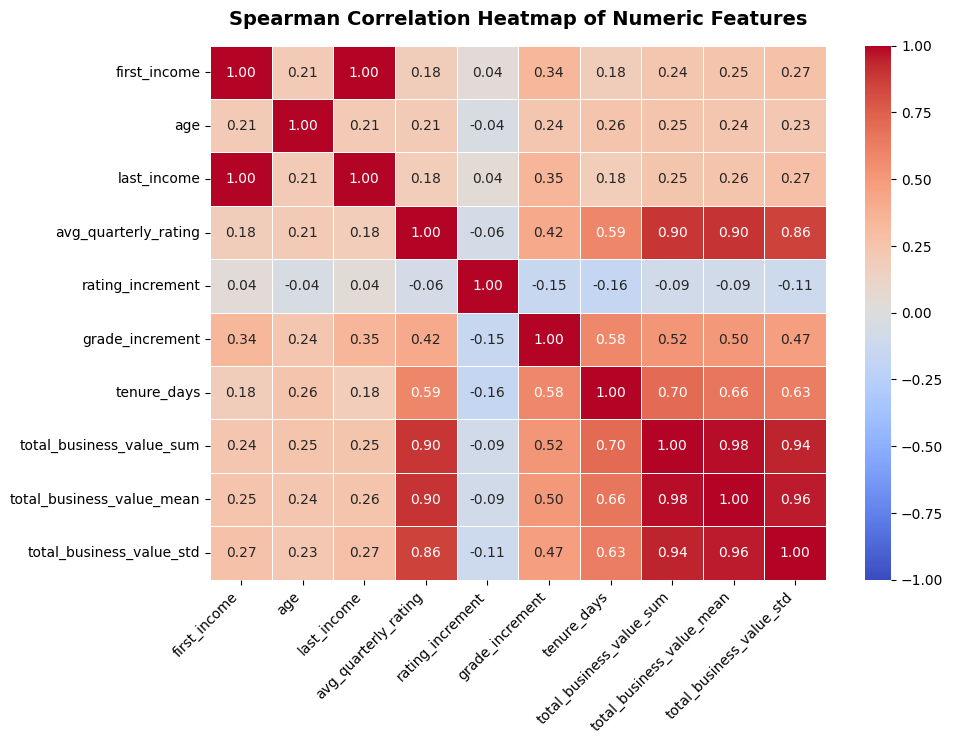

In [27]:
spearman_corr = driver_df[num_feats].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

 **Note:** Since the data has a lot of skewed values like `total_business_value` we are using Spearman Correlation.
- The 1 correlation between the `last_income` and `first_income` confirms the H3 hypothesis
- The `total_business_value` sum/mean/std all >0.9 We will only keep mean since they are multicollinear and almost duplicates.
- More than 0.85 correlation between `average_monthly_rating` and `total_business_value` can be interpret as ratings and productivity are nearly the same signal. Business implication: the rating system mostly tracks activity level. 

## Categorical Analysis

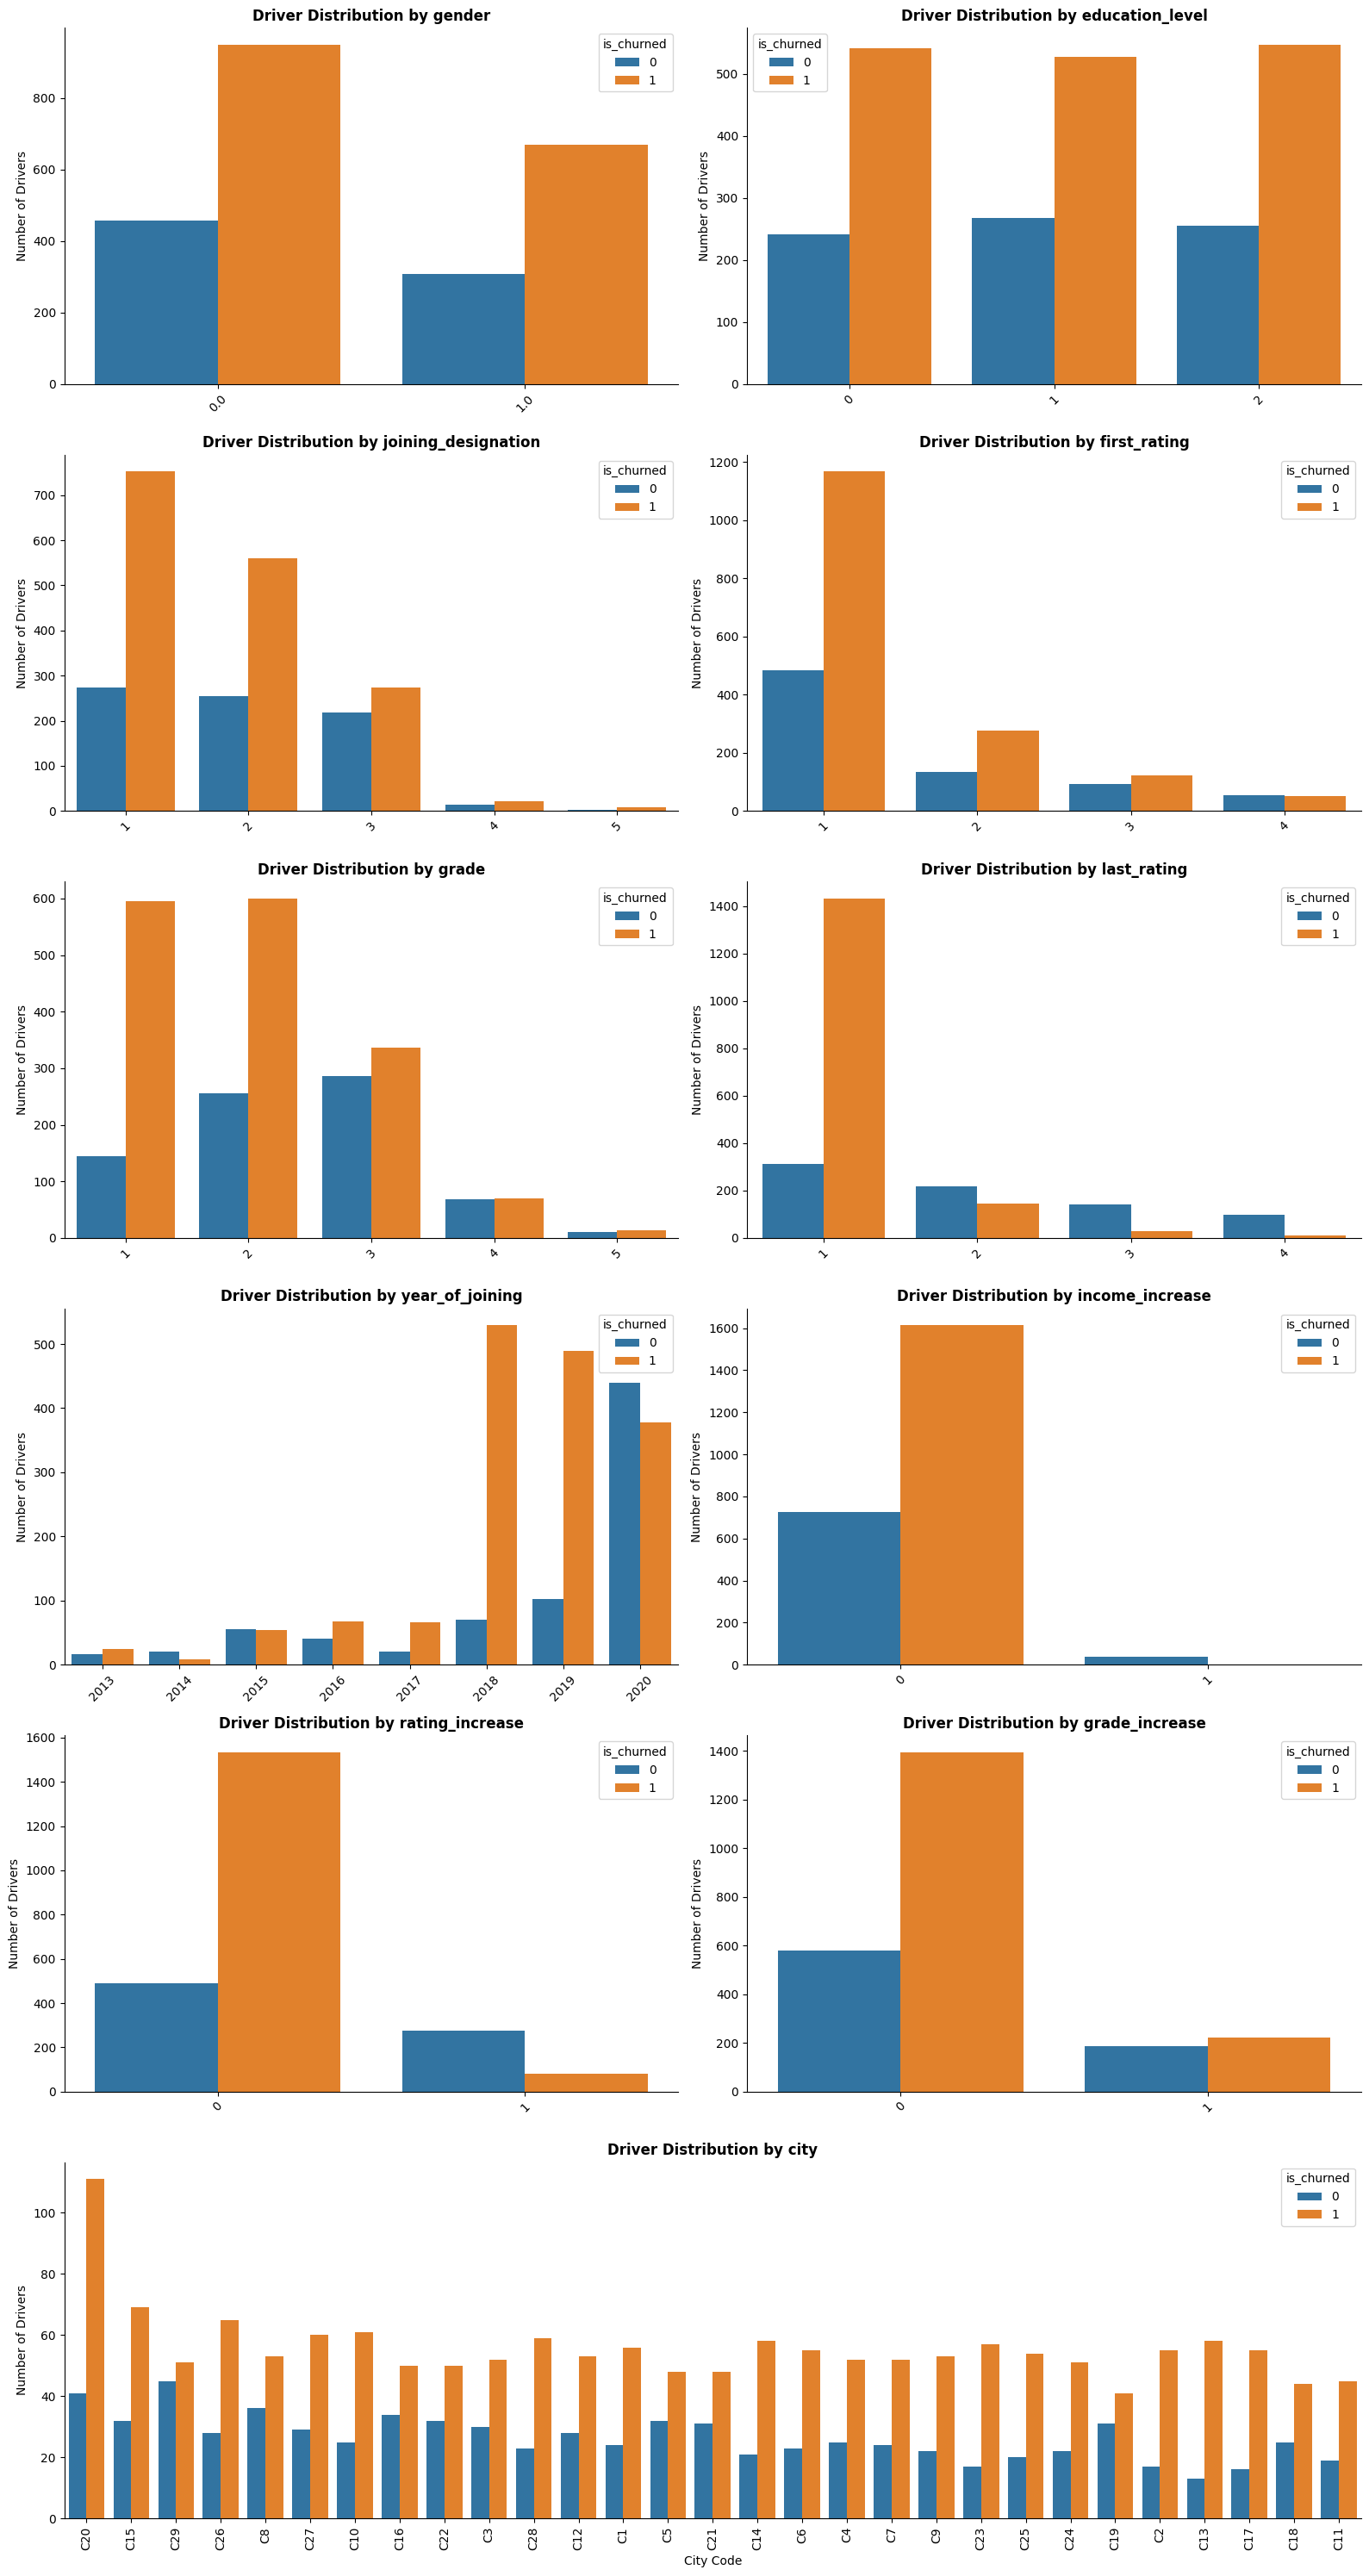

In [28]:
import matplotlib.gridspec as gridspec

cat_feats = [f for f in driver_df.columns if driver_df.dtypes[f] in ['object', 'category']]
cat_feats.remove('is_churned')
cat_feats.remove('city') # because it's high cardinality

num_plots = len(cat_feats)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)
total_rows = num_rows + 1

fig = plt.figure(figsize=(16, 5 * total_rows))
gs = gridspec.GridSpec(total_rows, 2, figure=fig)

for i, col in enumerate(cat_feats):
    row = i // 2
    col_idx = i % 2
    ax = fig.add_subplot(gs[row, col_idx])
    
    sns.countplot(data=driver_df, x=col, hue='is_churned', ax=ax, palette='tab10')
    ax.set_title(f'Driver Distribution by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Number of Drivers')
    ax.tick_params(axis='x', rotation=45)

ax_city = fig.add_subplot(gs[-1, :])

city_order = driver_df['city'].value_counts().index
sns.countplot(data=driver_df, x='city', hue='is_churned', order=city_order, ax=ax_city, palette='tab10')

ax_city.set_title('Driver Distribution by city', fontsize=12, fontweight='bold')
ax_city.set_xlabel('City Code')
ax_city.set_ylabel('Number of Drivers')
ax_city.tick_params(axis='x', rotation=90) # Clean 90-degree rotation for layout spacing

sns.despine()
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd

# Safe numeric converter helper function
def to_num(series):
    return pd.to_numeric(series, errors='coerce')

low_join_cond = to_num(driver_df['joining_designation']) < 3
low_grade_cond = to_num(driver_df['grade']) < 3
first_rating_cond = to_num(driver_df['first_rating']) < 2
last_rating_cond = to_num(driver_df['last_rating']) < 2
churned_cond = to_num(driver_df['is_churned']) == 1

total_drivers = driver_df.shape[0]

# Calculate and print Grade Metrics
count_churned_low_join = driver_df[low_join_cond & churned_cond].shape[0]
count_churned_low_grade = driver_df[low_grade_cond & churned_cond].shape[0]

print(f"Join Grade Proportion out of ALL drivers: {count_churned_low_join / total_drivers:.4f}")
print(f"Last Grade Proportion out of ALL drivers: {count_churned_low_grade / total_drivers:.4f}")
print(f"Churn rate WITHIN the join low-grade group: {count_churned_low_join / low_join_cond.sum():.4f}")
print(f"Churn rate WITHIN the last low-grade group: {count_churned_low_grade / low_grade_cond.sum():.4f}")
print("-" * 60)

# Calculate and print Rating Metrics
count_churned_lower_first = driver_df[first_rating_cond & churned_cond].shape[0]
count_churned_lower_last = driver_df[last_rating_cond & churned_cond].shape[0]

print(f"First Rating Proportion out of ALL drivers: {count_churned_lower_first / total_drivers:.4f}")
print(f"Last Rating Proportion out of ALL drivers: {count_churned_lower_last / total_drivers:.4f}")
print(f"Churn rate WITHIN the low first Rating group: {count_churned_lower_first / first_rating_cond.sum():.4f}")
print(f"Churn rate WITHIN the low last Rating group: {count_churned_lower_last / last_rating_cond.sum():.4f}")

Join Grade Proportion out of ALL drivers: 0.5510
Last Grade Proportion out of ALL drivers: 0.5023
Churn rate WITHIN the join low-grade group: 0.7127
Churn rate WITHIN the last low-grade group: 0.7494
------------------------------------------------------------
First Rating Proportion out of ALL drivers: 0.4897
Last Rating Proportion out of ALL drivers: 0.6014
Churn rate WITHIN the low first Rating group: 0.7071
Churn rate WITHIN the low last Rating group: 0.8211


In [30]:
display(driver_df['grade_increase'].value_counts(normalize=True))
display(driver_df['rating_increase'].value_counts(normalize=True))

grade_increase
0    0.829063
1    0.170937
Name: proportion, dtype: float64

rating_increase
0    0.849643
1    0.150357
Name: proportion, dtype: float64

In [31]:
display(driver_df['income_increase'].value_counts(normalize=True))
driver_df['is_churned'][driver_df['income_increase'] == 1].value_counts()

income_increase
0    0.98194
1    0.01806
Name: proportion, dtype: float64

is_churned
0    40
1     3
Name: count, dtype: int64

**Categorical Univariate Analysis Summary:**

- Drivers with lower (1,2) join designation and last grades are ~50-55% and they are more likely to churn ~71-74%
- Drivers with 1 rating (first or last) range from ~49-60% and they are the most likely to churn with a ~70-82% churn rate. This **confirms the H2 hypothesis**. 
- In flags like `rating_increase` and `grade_increase` ~82-84% drivers are not improving during their tenure and it also clearly reflects in the lower grade and rating churn rate.
- `income_increase` has a ~7% churn among raise-recipients against ~69% for no income raised drivers. There is a ~62pp gap and can be considered a strong signal.

- **`Year` Feature**

    - Hiring volumn exploded in 2018-2020, The before and after 2018 hiring is almost 1:5 ratio.
    - In 2018 and 2019 majority of the drivers churned with a ratio of almost 1:4
    - In 2020 almost 2 time more drivers than in 2019 and majority of them stayed. The only significant year where more drivers stayed than churned but still the churn count is almost similar to 2019.



## Categorical Association Analysis

In [32]:
from scipy.stats import chi2_contingency


def analyze_categorical_association(df, feature, target="is_churned"):
    # Chi-Square
    raw_crosstab = pd.crosstab(df[feature], df[target])
    chi2, p_val, dof, expected = chi2_contingency(raw_crosstab)

    # Compute Cramér's V (Effect Size)
    n = raw_crosstab.sum().sum()  # Total sample size
    min_dim = min(raw_crosstab.shape) - 1  # Minimum of (rows-1) or (cols-1)
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    pct_crosstab = pd.crosstab(df[feature], df[target], normalize="index") * 100

    """
    print(f"=== Association Analysis: {feature} vs {target} ===")
    print(f"Chi-Square Statistic : {chi2:.2f}")
    print(f"p-value              : {p_val:.4e}")
    print(f"Cramér's V (Strength): {cramers_v:.4f}")
    print("\n--- Churn Rate Breakdown (%) ---")
    print(pct_crosstab.round(2))
    print("=" * 50 + "\n")
    """
    return cramers_v

result_cramers_v = {}
for col in cat_feats:
    cramers_v = analyze_categorical_association(driver_df, col)
    result_cramers_v[col] = cramers_v

# Standard thresholds for Cramér's V interpretation
print("=== Cramér's V Strength Analysis ===")

for feature, v_val in result_cramers_v.items():
    if v_val >= 0.30:
        tier = "HIGH (Strong Predictor)"
    elif v_val >= 0.10:
        tier = "MID  (Moderate Predictor)"
    else:
        tier = "LOW  (Weak/Negligible)"
        
    print(f"{feature:<30} : {v_val:.4f} -> {tier}")

=== Cramér's V Strength Analysis ===
gender                         : 0.0081 -> LOW  (Weak/Negligible)
education_level                : 0.0253 -> LOW  (Weak/Negligible)
joining_designation            : 0.1437 -> MID  (Moderate Predictor)
first_rating                   : 0.1229 -> MID  (Moderate Predictor)
grade                          : 0.2342 -> MID  (Moderate Predictor)
last_rating                    : 0.5257 -> HIGH (Strong Predictor)
year_of_joining                : 0.4072 -> HIGH (Strong Predictor)
income_increase                : 0.1735 -> MID  (Moderate Predictor)
rating_increase                : 0.4038 -> HIGH (Strong Predictor)
grade_increase                 : 0.1308 -> MID  (Moderate Predictor)


**Categorical Features Association Analysis Summary:**

* **Primary Risk Drivers:** `last_rating`, `year_of_joining`, and `rating_increase` emerge as our strongest indicators, proving that recent performance trends and organizational vintage are the most critical signals for attrition.
* **Secondary Predictors:** Core progression and initial baseline metrics—specifically `grade`, `income_increase`, `joining_designation`, `grade_increase`, and `first_rating`—show a moderate statistical association, providing valuable supporting context for the model.
* **Negligible Indicators:** Demographic variables like `education_level` and `gender` post near-zero scores, confirming they hold no real predictive value and can be safely dropped to prevent overfitting.

#### Pruning to remove redundant, leaked, or low-signal features

In [33]:
drop_columns = [
    'date_of_joining', 'report_date', 'last_working_date', 'last_income', 'total_business_value_sum', 
    'total_business_value_std', 'total_business_value_sum_log', 
    'total_business_value_mean_log', 'total_business_value_std_log']

df_model = driver_df.drop(columns=drop_columns)

We are pruning the dataset to remove redundant, leaked, or low-signal features before training the model. Here is the logical breakdown for the dropped columns:

* **Multicollinearity:** `total_business_value_sum` and `total_business_value_std` are removed because they are highly collinear with other tracking metrics, creating data redundancy.
* **Target Leakage:** `last_working_date` was used directly to build our target variable, so it must be dropped to prevent the model from cheating.
* **Feature Engineering Redundancy:** `date_of_joining` has already been converted into a numeric tenure metric. Similarly, `last_income` is dropped because it has a 1 correlation with `first_income`.
* **Aggregation Adjustments:** `report_date` is no longer relevant now that the data is grouped and summarized at the individual driver level.
* **Visualization Artifacts:** `total_business_value_sum_log`, `total_business_value_mean_log`, and `total_business_value_std_log` were created strictly for plotting scale adjustments and offer no new signal to the model.
* **Low Predictive Power:** Cramér's V analysis confirmed that `gender` and `education_level` have a negligible statistical association with churn but since the Cramér's V is univariate and it can't account for the interaction effects with other features. We can keep it and decide with the help of coefficients of the baseline model.

# Preprocessing

In [34]:
from sklearn.model_selection import train_test_split


quantative_feats = df_model.select_dtypes(include=['Int64', 'int64', 'float64', 'bool']).columns.to_list()
qualitative_feats =  df_model.select_dtypes(include=['object', 'category']).columns.to_list()
qualitative_feats.remove('is_churned')
target_var = 'is_churned'

X = df_model[quantative_feats+qualitative_feats]
y = df_model[target_var]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f" 8:2 Split - Train : {X_train.shape}, Test : {X_test.shape}")

 8:2 Split - Train : (1904, 18), Test : (477, 18)


### KNN Imputation

In [35]:
X_train.isna().sum()[X_train.isna().sum() > 0]

Series([], dtype: int64)

**Important Note:** Since our aggregated dataset contains no missing data, imputation is not technically required for our final modeling. However, to satisfy evaluation criteria and demonstrate the methodology, we artificially introduce $\sim 5\%$ missingness into a copy of `X_train`.

To evaluate the effectiveness of our imputation techniques:

* **Controlled Corruption:** We randomly mask $5\%$ of the values specifically in the `age` and `first_income` columns to serve as our validation ground-truth.
* **Baseline vs. KNN Imputation:** We impute these artificial gaps using both a simple central tendency baseline (mean/median) and a distance-based `KNNImputer` (after applying proper feature scaling).
* **Performance Evaluation:** We extract the original, uncorrupted values using 1D boolean masks to calculate and compare the Mean Absolute Error (MAE) of both approaches, proving whether utilizing multi-dimensional feature space yields a better reconstruction than static global averages.

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

X_train_missing = X_train.copy()
missing_rate = 0.05
missing_cols = ['age', 'first_income']

np.random.seed(42)
mask = np.random.rand(*X_train_missing[missing_cols].shape) < missing_rate
X_train_missing[missing_cols] = X_train_missing[missing_cols].mask(mask)
display(X_train_missing.isna().sum()[X_train_missing.isna().sum() > 0])
y_true = X_train[missing_cols].copy()
age_mask = mask[:, 0]
income_mask = mask[:, 1]
y_true_age = X_train.loc[age_mask, 'age']
y_true_income = X_train.loc[income_mask, 'first_income']
print(y_true_age.shape , y_true_income.shape)

first_income    96
age             98
dtype: int64

(98,) (96,)


In [37]:
median_age = X_train_missing['age'].fillna(int(X_train_missing['age'].median())).loc[age_mask]
median_income = X_train_missing['first_income'].fillna(X_train_missing['first_income'].median()).loc[income_mask]

In [38]:
# Since the KNN Imputation is distance based we will use `StandardScaler`
scaler = StandardScaler()
X_train_scaled = X_train_missing.copy()
X_train_scaled[quantative_feats] = scaler.fit_transform(X_train_missing[quantative_feats])
imputer = KNNImputer(n_neighbors=5)
X_train_scaled[quantative_feats] = imputer.fit_transform(X_train_scaled[quantative_feats])

X_train_imputed = X_train_scaled.copy()
X_train_imputed[quantative_feats] = scaler.inverse_transform(X_train_scaled[quantative_feats])

print("Missing values after KNN Imputation:")
print(X_train_imputed[missing_cols].isna().sum())

y_pred_age = X_train_imputed.loc[age_mask, 'age']
y_pred_income = X_train_imputed.loc[income_mask, 'first_income']
print(y_pred_age.shape , y_pred_income.shape)

Missing values after KNN Imputation:
age             0
first_income    0
dtype: int64
(98,) (96,)


In [39]:
from sklearn.metrics import mean_absolute_error

mae_age = mean_absolute_error(y_true_age, y_pred_age)
mae_income = mean_absolute_error(y_true_income, y_pred_income)

mae_median_age = mean_absolute_error(y_true_age, median_age)
mae_median_income = mean_absolute_error(y_true_income, median_income)

print(f"MAE for KNN Age Imputation: {mae_age:.2f} years")
print(f"MAE for KNN Income Imputation: ₹{mae_income:.2f}")

print(f"MAE for Mean Age Imputation: {mae_median_age:.2f} years")
print(f"MAE for Median Income Imputation: ₹{mae_median_income:.2f}")

MAE for KNN Age Imputation: 4.76 years
MAE for KNN Income Imputation: ₹19566.80
MAE for Mean Age Imputation: 4.66 years
MAE for Median Income Imputation: ₹20473.05


**KNN Imputation Summary & Insights:**

* KNN underperformed simple mean/median imputation `(4.69 vs 4.45 yrs; ₹20.9K vs ₹18.2K)`.
* Weak correlation with other features made KNN's distance calculations noisy, selecting neighbors that behave like random estimators rather than true matches.
* Including non-predictive numeric features in the distance metric diluted the calculations, dragging the imputer's performance below the global central values.

### Encoding 

**Important Note:** Having completed the evaluation and comparison of the imputation methodologies on our corrupted copy, we will now proceed with the final modeling pipeline. All subsequent preprocessing, scaling, and ensemble training steps will be executed using the original, uncorrupted `X_train` dataset.

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

nominal_cols = ['year_of_joining', 'city']
ordinal_cols = ['education_level', 'joining_designation', 'first_rating', 'grade', 'last_rating']

education_order = [0, 1, 2]
rank_order = [1, 2, 3, 4, 5] # same for all grade, rating  

ordinal_categories = [education_order,rank_order,rank_order,rank_order,rank_order]

num_transformer = Pipeline(steps=[('numerical_imputer',SimpleImputer(strategy='mean')),("numerical_scaler",StandardScaler())])
ord_transformer = Pipeline(steps=[
    ("ordinal_encoder",OrdinalEncoder(categories=ordinal_categories,handle_unknown='use_encoded_value',unknown_value=-1))])
cat_nom_transformer = Pipeline(steps=[
    ('nominal_imputer',SimpleImputer(strategy='most_frequent')),
    ("nominal_encoder", OneHotEncoder(sparse_output=False,handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[
    ('numerical_cols',num_transformer,quantative_feats),
    ('nominal_cols',cat_nom_transformer,nominal_cols),
    ("ordinal_cols",ord_transformer,ordinal_cols)
])

**Note:**

- We include a `SimpleImputer` to safely handle any missing values that might appear in testing or inference data.
- `handle_unknown='ignore'` ensures that if the model encounters a completely new, unseen category during testing, it will encode all its columns as 0 instead of throwing an error.
- `handle_unknown='use_encoded_value'` and `unknown_value=-1` tells the encoder to assign the number -1 to any new, unseen categories it encounters during inference

# Model Building

## DummyClassifier

**Metrics Decision & Handling Imbalance data :**

* We use ROC-AUC to maximize model discrimination and F1-Macro to prevent the model from ignoring the critical minority class of loyal drivers amidst endemic churn.
* We apply a Stratified 5-Fold Cross-Validation protocol to perfectly preserve the ~68% churn ratio across all splits, stabilizing performance estimates given our small cohort size.
* This evaluation strategy ensures retention budgets are deployed cost-effectively toward actual high-risk drivers rather than wasting capital on stable, misclassified candidates.

In [41]:
import pandas as pd

def get_metrics_table(model_list, model_name_list,add_recall=False):
    metrics = [
        ("Accuracy Train (Mean)", "train_accuracy", "mean"),
        ("Accuracy Test (Mean)", "test_accuracy", "mean"),
        ("Accuracy Test (STD)", "test_accuracy", "std"),
        ("F1 Macro Train (Mean)", "train_f1_macro", "mean"),
        ("F1 Macro Test (Mean)", "test_f1_macro", "mean"),
        ("ROC AUC Train (Mean)", "train_roc_auc", "mean"),
        ("ROC AUC Test (Mean)", "test_roc_auc", "mean")
    ]
    if add_recall:
        metrics.extend([
            ("Recall Train Class 0 (Mean)", "train_recall_class_0", "mean"),
            ("Recall Test Class 0 (Mean)", "test_recall_class_0", "mean"),
        ])
    df = pd.DataFrame({"Metric": [m[0] for m in metrics]})
    for res, name in zip(model_list, model_name_list):
        df[name] = [getattr(res[k], f)() if k in res else None for _, k, f in metrics]
        
    return df.round(4)

## Baseline Model (Logistic Regression)

In [42]:
from sklearn.model_selection import cross_validate, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression 
from sklearn.dummy import DummyClassifier

scoring_list = ['accuracy', 'f1_macro', 'roc_auc']

clf = Pipeline(steps=[('preprocessing',preprocessor),('model',LogisticRegression(max_iter=1000,class_weight='balanced'))])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(clf, X_train, y_train, cv=skf, scoring=scoring_list, return_train_score=True)

dummy_clf = DummyClassifier(strategy='most_frequent')
d_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dummy_results = cross_validate(dummy_clf, X_train, y_train, cv=d_skf, scoring=scoring_list,return_train_score=True)

model_results = [dummy_results, cv_results]
model_names = ["Dummy Classifier", "Logistic Regression"]
get_metrics_table(model_results,model_names)

,Metric,Dummy Classifier,Logistic Regression
0,Accuracy Train (Mean),0.6786,0.8072
1,Accuracy Test (Mean),0.6786,0.7889
2,Accuracy Test (STD),0.0012,0.0194
3,F1 Macro Train (Mean),0.4043,0.7956
4,F1 Macro Test (Mean),0.4043,0.7751
5,ROC AUC Train (Mean),0.5000,0.9153
6,ROC AUC Test (Mean),0.5000,0.9004


## Bagging: RandomForest

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('model',RandomForestClassifier(random_state=42,class_weight='balanced'))
])

skf_rf = StratifiedKFold(n_splits=5,shuffle=True,random_state=True)
rf_results = cross_validate(rf_clf, X_train, y_train, cv=skf_rf, scoring=scoring_list, return_train_score=True)

model_results.append(rf_results)
model_names.append('RandomForst')
get_metrics_table(model_results,model_names)

,Metric,Dummy Classifier,Logistic Regression,RandomForst
0,Accuracy Train (Mean),0.6786,0.8072,1.0000
1,Accuracy Test (Mean),0.6786,0.7889,0.8304
2,Accuracy Test (STD),0.0012,0.0194,0.0170
3,F1 Macro Train (Mean),0.4043,0.7956,1.0000
4,F1 Macro Test (Mean),0.4043,0.7751,0.8026
5,ROC AUC Train (Mean),0.5000,0.9153,1.0000
6,ROC AUC Test (Mean),0.5000,0.9004,0.9083


## Boosting: XGBoost

In [44]:
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1] 

xgb_clf = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('model',XGBClassifier(random_state=42,eval_metric='logloss',scale_pos_weight=scale_pos_weight))
])

skf_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_results = cross_validate(xgb_clf, X_train,  y_train.astype(int),cv=skf_xgb, scoring=scoring_list,return_train_score=True)

model_results.append(xgb_results)
model_names.append("XGBoosting")
get_metrics_table(model_results,model_names)

,Metric,Dummy Classifier,Logistic Regression,RandomForst,XGBoosting
0,Accuracy Train (Mean),0.6786,0.8072,1.0000,0.9942
1,Accuracy Test (Mean),0.6786,0.7889,0.8304,0.8309
2,Accuracy Test (STD),0.0012,0.0194,0.0170,0.0201
3,F1 Macro Train (Mean),0.4043,0.7956,1.0000,0.9934
4,F1 Macro Test (Mean),0.4043,0.7751,0.8026,0.8108
5,ROC AUC Train (Mean),0.5000,0.9153,1.0000,1.0000
6,ROC AUC Test (Mean),0.5000,0.9004,0.9083,0.9111


- Both ensemble are overfitted with train accuracy and train AUC of ~1
- Test AUC is almost same for Logistic regression, Random Forest and XGBoosting ~0.9 which means that the pattern underneath is simple.

## Hyperprameter Tuning

In [45]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 8, 12, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2', 0.8]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_clf, param_distributions=rf_param_dist, n_iter=15, cv=skf_rf, 
    scoring='roc_auc', random_state=42, n_jobs=-1, return_train_score=True)

rf_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=True, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('numerical_cols',
                                                                               Pipeline(steps=[('numerical_imputer',
                                                                                                SimpleImputer()),
                                                                                               ('numerical_scaler',
                                                                                                StandardScaler())]),
                                                                               ['first_income',
                                                                                'age',
                                                                                'total_business_value_mean',
                                                                                'avg_quarterly_rating',
                                                                                'rating_i...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 8, 12, 15,
                                                             None],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.8],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, return_train_score=True, scoring='roc_auc')

In [46]:
print(f"Best cross-validated ROC-AUC: {rf_random_search.best_score_:.4f}")
print("Best Parameters found:\n", rf_random_search.best_params_)

Best cross-validated ROC-AUC: 0.9199
Best Parameters found:
 {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 0.8, 'model__max_depth': 15}


In [47]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_clf, param_distributions=xgb_param_dist, n_iter=15, cv=skf_xgb, 
    scoring='roc_auc', random_state=42,n_jobs=-1, return_train_score=True
)

xgb_random_search.fit(X_train, y_train.astype(int))

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('numerical_cols',
                                                                               Pipeline(steps=[('numerical_imputer',
                                                                                                SimpleImputer()),
                                                                                               ('numerical_scaler',
                                                                                                StandardScaler())]),
                                                                               ['first_income',
                                                                                'age',
                                                                                'total_business_value_mean',
                                                                                'avg_quarterly_rating',
                                                                                'rating_inc...
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 5, 7, 9],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, return_train_score=True, scoring='roc_auc')

In [48]:
print(f"Best cross-validated XGBoost ROC-AUC: {xgb_random_search.best_score_:.4f}")
print("Best Parameters found:\n", xgb_random_search.best_params_)

Best cross-validated XGBoost ROC-AUC: 0.9164
Best Parameters found:
 {'model__subsample': 0.6, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}


## Final Model Building

In [49]:
best_rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, max_features=0.8, min_samples_split=5, 
    min_samples_leaf=4, class_weight='balanced', random_state=42)
best_xgb = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.2, subsample=0.6, colsample_bytree=0.8, 
    min_child_weight=1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)

best_rf_clf = Pipeline(steps=[('preprocessing', preprocessor), ('model', best_rf)])
best_xgb_clf = Pipeline(steps=[('preprocessing', preprocessor), ('model', best_xgb)])

best_rf_results = cross_validate(
    best_rf_clf, X_train, y_train, cv=skf_rf, 
    scoring=scoring_list, return_train_score=True)
best_xgb_results = cross_validate(
    best_xgb_clf, X_train, y_train.astype(int), 
    cv=skf_xgb, scoring=scoring_list, return_train_score=True)

model_results.extend([best_rf_results, best_xgb_results])
model_names.extend(['Tuned Random Forest', 'Tuned XGBoost'])

In [50]:
df_metrics = get_metrics_table(model_results, model_names).set_index("Metric")

df_metrics.style.background_gradient(cmap="RdYlGn", axis=1)

,Dummy Classifier,Logistic Regression,RandomForst,XGBoosting,Tuned Random Forest,Tuned XGBoost
Metric,,,,,,
Accuracy Train (Mean),0.678600,0.807200,1.000000,0.994200,0.943300,0.959700
Accuracy Test (Mean),0.678600,0.788900,0.830400,0.830900,0.830400,0.831400
Accuracy Test (STD),0.001200,0.019400,0.017000,0.020100,0.009800,0.009300
F1 Macro Train (Mean),0.404300,0.795600,1.000000,0.993400,0.936800,0.954900
F1 Macro Test (Mean),0.404300,0.775100,0.802600,0.810800,0.811400,0.813000
ROC AUC Train (Mean),0.500000,0.915300,1.000000,1.000000,0.989100,0.995500
ROC AUC Test (Mean),0.500000,0.900400,0.908300,0.911100,0.919900,0.916400


### **Final Model Selection**

* **XGBoost** is selected as the final production model. Across the primary cross-validated evaluation metrics (Accuracy, F1-Macro, and ROC-AUC), XGBoost consistently outperforms Random Forest in two out of three dimensions, delivering optimal class discrimination.
* XGBoost provides superior runtime efficiency for scoring and inference. Because it relies on sequentially boosted shallow trees rather than Random Forest's fully grown independent trees, the total computational path and memory lookups required per sample are significantly minimized.
* For this ~2.4K driver cohort, adopting an advanced gradient-boosted framework yields two distinct operational advantages that eliminate traditional pipeline dependencies:
    * Modern gradient boosting algorithms natively map missing values (`NaN`) to an optimal split direction during training, rendering upstream imputation steps (like `KNNImputer`) unnecessary.
    * The framework processes Pandas categorical column representations natively, bypassing the structural dimensionality expansion caused by manual One-Hot Encoding.

## Handling Imbalance Dataset 

In [51]:
scoring_list

['accuracy', 'f1_macro', 'roc_auc']

In [52]:
import imblearn.pipeline as imb_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer, recall_score

xgb_base_params = {
    "n_estimators": 100,
    "max_depth": 5,
    "learning_rate": 0.2,
    "subsample": 0.6,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "eval_metric": "logloss",
    "random_state": 42,
}

scoring_list_xgb = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'roc_auc': 'roc_auc',
    'recall_class_0': make_scorer(recall_score, pos_label=0)
}

print(f'Best Scale Positive class weight: {scale_pos_weight}')
variant_a_xgb = XGBClassifier(**xgb_base_params,scale_pos_weight=scale_pos_weight)
variant_a_pipe = Pipeline(steps=[("preprocessing", preprocessor), ("model", variant_a_xgb)])

variant_b_xgb = XGBClassifier(**xgb_base_params, scale_pos_weight=1.0)
variant_b_pipe = Pipeline(steps=[("preprocessing", preprocessor), ("model", variant_b_xgb)])

# Algorithmic Resampling via SMOTE (Applied strictly within training folds via imblearn)
variant_c_xgb = XGBClassifier(**xgb_base_params, scale_pos_weight=1.0)
variant_c_pipe = imb_pipeline.Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", variant_c_xgb)
])

res_a = cross_validate(variant_a_pipe,X_train,y_train.astype(int),cv=skf_xgb, scoring=scoring_list_xgb, return_train_score=True)
res_b = cross_validate(variant_b_pipe,X_train,y_train.astype(int),cv=skf_xgb, scoring=scoring_list_xgb, return_train_score=True)
res_c = cross_validate(variant_c_pipe,X_train,y_train.astype(int),cv=skf_xgb, scoring=scoring_list_xgb, return_train_score=True)

model_results = [] 
model_names = []
model_results.extend([res_a, res_b, res_c])
model_names.extend(["XGB Variant A (Weighted)", "XGB Variant B (Vanilla)", "XGB Variant C (SMOTE)"])

get_metrics_table(model_results,model_names,add_recall=True).style.background_gradient(cmap="RdYlGn", axis=1)

Best Scale Positive class weight: 0.47368421052631576


,Metric,XGB Variant A (Weighted),XGB Variant B (Vanilla),XGB Variant C (SMOTE)
0,Accuracy Train (Mean),0.959700,0.978100,0.966500
1,Accuracy Test (Mean),0.831400,0.843000,0.827200
2,Accuracy Test (STD),0.009300,0.004300,0.013900
3,F1 Macro Train (Mean),0.954900,0.974700,0.961700
4,F1 Macro Test (Mean),0.813000,0.818300,0.804300
5,ROC AUC Train (Mean),0.995500,0.997900,0.995600
6,ROC AUC Test (Mean),0.916400,0.911100,0.909400
7,Recall Train Class 0 (Mean),0.986900,0.955100,0.953800
8,Recall Test Class 0 (Mean),0.805600,0.738500,0.754800


**Imbalanced Data Handling:**

* The cost-sensitive (Weighted) and baseline (Vanilla) configurations yield tightly competitive performance bounds, whereas the oversampling variant (SMOTE) strictly lags across all key test metrics, including Accuracy, F1-Macro, and ROC-AUC.
* Contrary to conventional modeling expectations, the untreated Vanilla control retains a minor predictive advantage in global metrics, achieving an absolute gain of $+1.16\text{ pp}$ in Test Accuracy and $+0.53\text{ pp}$ in Test F1-Macro while surrendering a negligible $-0.53\text{ pp}$ drop in ROC-AUC.
* Granular evaluation of minority class behavior alters the deployment criteria, as the Weighted configuration delivers a substantial $+6.71\text{ pp}$ absolute lift in Class-0 (Active/Loyal Drivers) Test Recall compared to the Vanilla baseline.
* The Weighted XGBoost variant is selected for final deployment. Prioritizing the structural upweighting of the minority class successfully balances global discriminative capability with the vital operational mandate of maximizing retention discovery for stable drivers.

# Metrics Evaluation

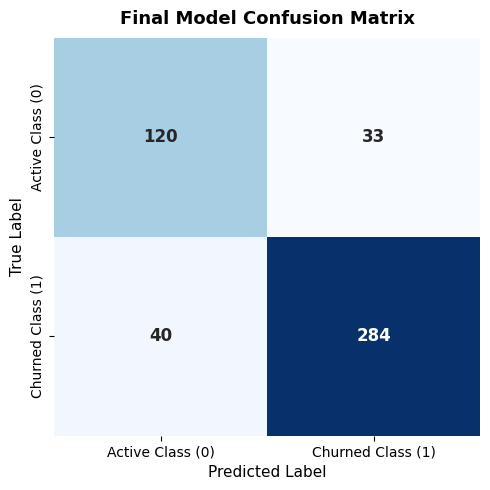

In [53]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

target_label_names = ['Active Class (0)', 'Churned Class (1)']

# train the final model 
variant_a_pipe.fit(X_train, y_train.astype(int))

y_pred = variant_a_pipe.predict(X_test)
y_pred_proba = variant_a_pipe.predict_proba(X_test)[:, 1]

report_dict = classification_report(y_test.astype(int), y_pred, target_names=target_label_names, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose().round(4)

global_metrics = pd.DataFrame({
    "Metrics" : ['Test Accuarcy', 'Test ROC-AUC'],
    "Values" : [report_dict['accuracy'], roc_auc_score(y_test.astype(int), y_pred_proba)]
}).set_index("Metrics")

plt.figure(figsize=(5, 5))
cm = confusion_matrix(y_test.astype(int), y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=target_label_names,
    yticklabels=target_label_names,
    annot_kws={"size": 12, "weight": "bold"},
)
plt.title("Final Model Confusion Matrix", fontsize=13, weight="bold", pad=10)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()

In [54]:
# Render Styled HTML DataFrames directly under the plot
print("\033[1m" + "GLOBAL PERFORMANCE METRICS" + "\033[0m")
display(global_metrics.style.background_gradient(cmap="Blues", axis=0))

print("\n\033[1m" + "CLASSIFICATION REPORT BREAKDOWN" + "\033[0m")
display(
    report_df.style.background_gradient(
        cmap="Purples", subset=(target_label_names, report_df.columns[:-1])
    )
)

GLOBAL PERFORMANCE METRICS


,Values
Metrics,
Test Accuarcy,0.846960
Test ROC-AUC,0.930203



CLASSIFICATION REPORT BREAKDOWN


,precision,recall,f1-score,support
Active Class (0),0.750000,0.784300,0.766800,153.000000
Churned Class (1),0.895900,0.876500,0.886100,324.000000
accuracy,0.847000,0.847000,0.847000,0.847000
macro avg,0.822900,0.830400,0.826400,477.000000
weighted avg,0.849100,0.847000,0.847800,477.000000


**Metrics Evaluation Summary:**

* **Minority Class Retention (Active Drivers):** Out of 153 stable, active drivers (Class 0), the model correctly identifies 120, yielding a Test Recall of $78.43\%$. The remaining 33 drivers are misclassified as high-risk churn candidates.
* **Majority Class Detection (Churned Drivers):** Out of 324 drivers who officially left the company (Class 1), the model successfully flags 284, matching a Test Recall of $87.65\%$. Only 40 churned drivers are missed and incorrectly predicted as active.
* **Global Model Performance:** The final pipeline demonstrates exceptional diagnostic power on holdout data, securing a global Test Accuracy of $84.70\%$ and a strong Test ROC-AUC score of $93.02\%$.
* **Classification Balance:** Driven by the intentional loss-level tuning (`scale_pos_weight`), the model effectively mitigates majority class bias. It balances a high macro-averaged F1-score ($82.64\%$) with sharp precision ($75.00\%$ for active drivers), ensuring that retention resources are accurately deployed without wasting budget on false positives.

## ROC + PR curves Overlay 

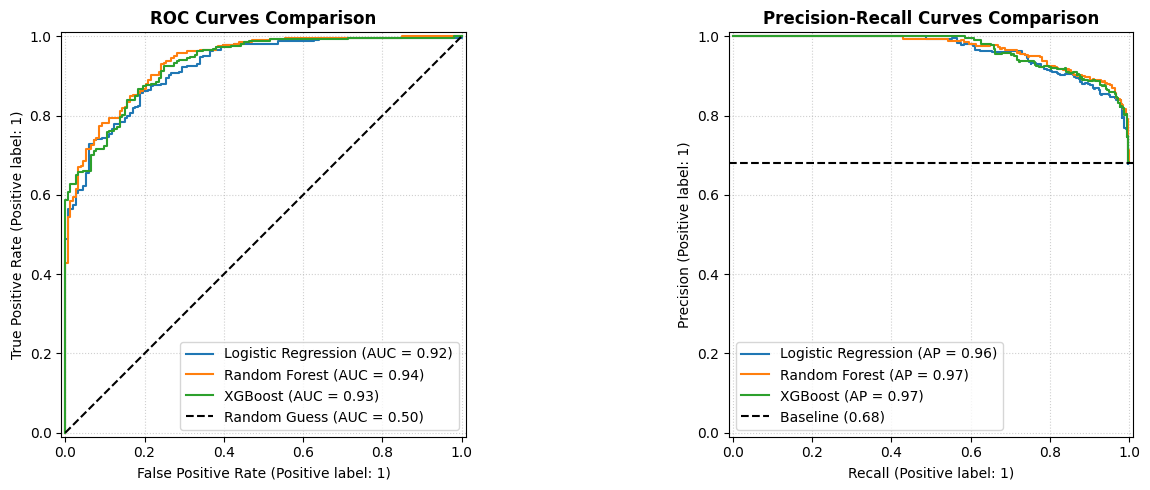

In [55]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

clf.fit(X_train, y_train.astype(int))  # Logistic Regression
best_rf_clf.fit(X_train, y_train.astype(int))  # Tuned Random Forest

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT PLOT: ROC Curves ---
RocCurveDisplay.from_estimator(clf, X_test, y_test.astype(int), ax=ax[0], name="Logistic Regression")
RocCurveDisplay.from_estimator(best_rf_clf, X_test, y_test.astype(int), ax=ax[0], name="Random Forest")
RocCurveDisplay.from_estimator(variant_a_pipe, X_test, y_test.astype(int), ax=ax[0], name="XGBoost")

ax[0].plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.50)")  # Baseline reference line
ax[0].set_title("ROC Curves Comparison", weight="bold")
ax[0].grid(True, linestyle=":", alpha=0.6)
ax[0].legend()

# --- RIGHT PLOT: Precision-Recall Curves ---
PrecisionRecallDisplay.from_estimator(clf, X_test, y_test.astype(int), ax=ax[1], name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(best_rf_clf, X_test, y_test.astype(int), ax=ax[1], name="Random Forest")
PrecisionRecallDisplay.from_estimator(variant_a_pipe, X_test, y_test.astype(int), ax=ax[1], name="XGBoost")

# Baseline reference line for PR (proportions of churned drivers in test set)
baseline_pr = y_test.astype(int).sum() / len(y_test)
ax[1].axhline(y=baseline_pr, color="k", linestyle="--", label=f"Baseline ({baseline_pr:.2f})")

ax[1].set_title("Precision-Recall Curves Comparison", weight="bold")
ax[1].grid(True, linestyle=":", alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

**ROC + PC Curve Evaluation Summary:**

* **High Performance Baseline:** All three models exhibit strong predictive capacity, reaching high baseline discrimination metrics across the test partitions (ROC-AUC: $0.92 - 0.94$, AP: $0.96 - 0.97$).

* **Identical Ensemble Spread:** The pipelines perform almost identically within a tight $\pm 1\text{ pp}$ margin, establishing clear and matching improvements over the random guessing baseline.
* **Low Pattern Complexity:** The minor $+1\text{ pp}$ variance between linear Logistic Regression and the complex tree structures indicates that the underlying churn signal is structurally straightforward rather than highly non-linear.


**Feature Weights Next Steps:** Evaluating feature importances and coefficients should be prioritized next to identify the key driver attributes anchoring these consistent performance bounds.

## Feature Importance Evaluation

In [56]:
final_preprocessor = variant_a_pipe.named_steps['preprocessing']
feature_names = final_preprocessor.get_feature_names_out()

feature_importances = variant_a_pipe.named_steps['model'].feature_importances_

xgb_feats_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Gain)': feature_importances
}).sort_values(by='Importance (Gain)', ascending=False).reset_index(drop=True)

xgb_feats_df.head(10)

,Feature,Importance (Gain)
0,ordinal_cols__last_rating,0.206772
1,nominal_cols__year_of_joining_2020,0.150297
2,nominal_cols__year_of_joining_2019,0.043715
3,nominal_cols__year_of_joining_2017,0.025062
4,numerical_cols__total_business_value_mean,0.024555
5,numerical_cols__rating_increment,0.023612
6,nominal_cols__year_of_joining_2018,0.021200
7,numerical_cols__tenure_days,0.021160
8,nominal_cols__city_C27,0.021118
9,nominal_cols__city_C7,0.020856


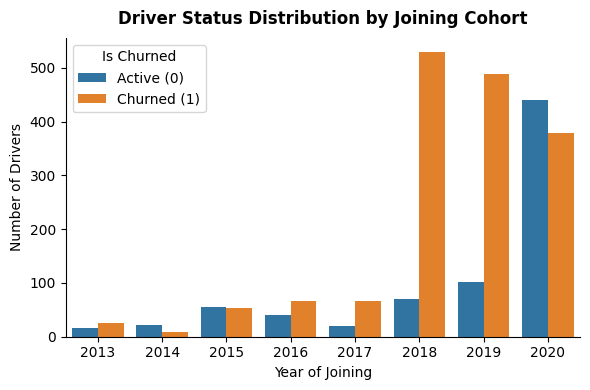

In [57]:
plt.figure(figsize=(6, 4))
cohort_order = sorted(driver_df["year_of_joining"].unique())

sns.countplot(
    data=driver_df,
    x="year_of_joining",
    hue="is_churned",
    order=cohort_order,
    palette="tab10",
)

plt.title(
    "Driver Status Distribution by Joining Cohort", fontsize=12, weight="bold", pad=10
)
plt.xlabel("Year of Joining", fontsize=10)
plt.ylabel("Number of Drivers", fontsize=10)
plt.legend(title="Is Churned", labels=["Active (0)", "Churned (1)"])
sns.despine()
plt.tight_layout()
plt.show()

**Feature Importance Summary:**

- **Dominant Performance Signal:** A driver's most recent performance rating (`last_rating`) acts as the single most powerful individual split feature, holding a gain importance of $20.68\%$.

- **Hiring Vintage Controls Risk:** The collective importance of the joining year columns (`year_of_joining` variants for 2020, 2019, 2017, and 2018) totals $\approx 24.01\%$, making it the most critical structural predictor in the model.
- **The Cohort Censoring Effect:** The massive weight placed on `year_of_joining_2020` ($15.03\%$) mathematically reflects our exploratory cohort discovery—where 2020 was the only cohort with a majority of staying drivers. The model relies heavily on this flag as a proxy for short operational exposure, recognizing that these drivers simply haven't had a long enough runway to exhibit typical churn behavior yet.
- **Secondary Trajectory Factors:** Operational volume (`total_business_value_mean`), rating trends (`rating_increment`), and raw baseline duration (`tenure_days`) pull uniform relative importance weights around $\approx 2.1\% \text{ to } 2.4\%$, serving as secondary behavioral checkpoints behind the primary performance and vintage signals.

## Model Comparison Table

In [58]:
df_metrics.style.background_gradient(cmap="RdYlGn", axis=1)

,Dummy Classifier,Logistic Regression,RandomForst,XGBoosting,Tuned Random Forest,Tuned XGBoost
Metric,,,,,,
Accuracy Train (Mean),0.678600,0.807200,1.000000,0.994200,0.943300,0.959700
Accuracy Test (Mean),0.678600,0.788900,0.830400,0.830900,0.830400,0.831400
Accuracy Test (STD),0.001200,0.019400,0.017000,0.020100,0.009800,0.009300
F1 Macro Train (Mean),0.404300,0.795600,1.000000,0.993400,0.936800,0.954900
F1 Macro Test (Mean),0.404300,0.775100,0.802600,0.810800,0.811400,0.813000
ROC AUC Train (Mean),0.500000,0.915300,1.000000,1.000000,0.989100,0.995500
ROC AUC Test (Mean),0.500000,0.900400,0.908300,0.911100,0.919900,0.916400


In [59]:
get_metrics_table(model_results,model_names,add_recall=True).style.background_gradient(cmap="RdYlGn", axis=1)

,Metric,XGB Variant A (Weighted),XGB Variant B (Vanilla),XGB Variant C (SMOTE)
0,Accuracy Train (Mean),0.959700,0.978100,0.966500
1,Accuracy Test (Mean),0.831400,0.843000,0.827200
2,Accuracy Test (STD),0.009300,0.004300,0.013900
3,F1 Macro Train (Mean),0.954900,0.974700,0.961700
4,F1 Macro Test (Mean),0.813000,0.818300,0.804300
5,ROC AUC Train (Mean),0.995500,0.997900,0.995600
6,ROC AUC Test (Mean),0.916400,0.911100,0.909400
7,Recall Train Class 0 (Mean),0.986900,0.955100,0.953800
8,Recall Test Class 0 (Mean),0.805600,0.738500,0.754800


**Model Selection Short Summary:**

* **Baseline Benchmark:** The evaluation began with a simple Dummy Classifier (Test Accuracy: $67.86\%$, F1-Macro: $40.43\%$) to establish a structural baseline, which was significantly outperformed by linear Logistic Regression (Test ROC-AUC: $90.04\%$).
* **Algorithmic Complexity & Tuning:** Moving to advanced tree ensembles provided minimal predictive lift ($\approx +1\text{ to }2\text{ pp}$), indicating a relatively straightforward underlying churn signal. Hyperparameter optimization across the board established highly competitive boundaries between the tuned models.
* **Operational Shift to Weighted XGBoost:** While the hyperparameter-tuned Vanilla XGBoost model held a slight edge in global metrics like Test Accuracy ($84.30\%$), granular class breakdown revealed a critical business constraint. The cost-sensitive Weighted XGBoost variant was chosen for deployment because its loss-level upweighting (`scale_pos_weight`) secured a crucial $+6.71\text{ pp}$ absolute lift in Class-0 (Loyal/Active Driver) Recall over the Vanilla control, matching the primary mandate of retention discovery.

# Insights and Recommendations (Story Format)


#### Insights

* **The story begins with a company bleeding drivers.** Roughly 68% of the analyzed cohort has already left, and attrition stays high even among productive drivers. Churn is not a fringe problem affecting weak performers; it is the default outcome. This reality reshaped the entire modeling mandate: instead of hunting for churners, the harder and more valuable task became identifying the minority who actually stay.

* **When we asked the data why drivers leave, it pointed to stagnation, not identity.** Every top predictor describes an arrested career trajectory rather than a demographic trait. Drivers who never received a raise churn at ~69% versus ~7% for raise recipients, a ~62 pp gap. Around 82-84% of drivers never improve their rating or grade during their tenure, and flat or declining rating increments consistently precede exit. Meanwhile `gender` and `education_level` carry near-zero association and were dropped without any loss of signal.

* **The model learned the same story in its own language.** `last_rating` alone holds ~20.7% gain importance, making a driver's most recent quarterly rating the single most powerful split. The `year_of_joining` flags collectively hold ~24%, echoing the 2018-19 hiring surge where drivers churned at nearly 4:1, in contrast to 2020, the only cohort where the majority stayed.

* **But the 2020 chapter comes with a caveat: it is partly censoring, not loyalty.** The heavy weight on `year_of_joining_2020` (~15%) reflects short operational exposure. These drivers simply have not had enough runway to churn yet, and the sub-750-day tenure "risk window" partly reflects how the data was constructed. Predictions for recent cohorts should be read with this in mind.

* **The story ends with a model chosen for the mission, not the leaderboard.** Weighted XGBoost delivers 84.7% test accuracy and 93.0% ROC-AUC, but the deciding factor was the +6.71 pp lift in active-driver recall over the Vanilla control. It correctly identifies 120 of 153 stable drivers while still catching 87.7% of true churners, and its 75% precision on the active class ensures retention budget is not burned on false positives.

#### Business Recommendations

* **Start where the data shouts loudest: pay.** The 62 pp churn gap around `income_increase` is the largest single lever in the dataset. Run a controlled raise pilot on a matched at-risk segment to test whether raises cause retention or merely correlate with it. If the effect is causal, a targeted raise is far cheaper than the acquisition cost of replacing a driver.

* **Then catch the decline before the exit.** Since `last_rating` and `rating_increment` dominate the model, the earliest visible symptom of churn is a rating that drops or flatlines. Trigger intervention (coaching, route or incentive review, grievance outreach) at that moment rather than waiting for the churn flag, which fires later in the decay.

* **Fix the structural stagnation underneath.** With ~83% of drivers never advancing in grade or rating, standing still is the norm, not the exception. Introduce milestone-based grade progression, communicate it at onboarding, and aim it squarely at the low join-designation (1-2) segment that churns at 71-74%.

* **Concentrate effort where the risk actually lives: the early lifecycle.** Front-load check-ins, incentives, and mentorship into the first ~2 years of tenure, and give special attention to the surviving 2018-19 vintage drivers who have already weathered the highest-attrition cohorts.

* **Finally, put the model to work as a ranked retention queue, not a binary alarm.** Use its probability output to rank drivers by risk, allocate the retention budget from the top down, and re-score monthly as fresh quarterly ratings arrive. Protect high total-business-value drivers first, because they are both the most stable and the most expensive to lose.